# 沐曦GPU运行TotalSegmentator说明文档

[TotalSegmentator](https://github.com/wasserth/TotalSegmentator)是一款基于[nnUNet](https://github.com/MIC-DKFZ/nnUNet)模型的CT图像分割工具。除了默认的 `total`（117个类别） 任务，该工具还提供多种细分任务。本文档介绍如何在沐曦 GPU 上运行 TotalSegmentator 。

## 1. 安装
### 1.1 环境准备
使用沐曦开发者社区提供的[maca-pytorch镜像](https://developer.metax-tech.com/softnova/docker?chip_name=%E6%9B%A6%E4%BA%91C500%E7%B3%BB%E5%88%97&package_name=maca-pytorch:3.8.0.11-torch2.6-py310-ubuntu24.04-amd64)启动容器：

```bash
docker run -it --name test-totalseg --device=/dev/mxcd --device=/dev/dri --group-add video --shm-size=8G --security-opt seccomp=unconfined --ulimit memlock=-1  --ulimit stack=67108864 -v /workspace:/workspace cr.metax-tech.com/public-library/maca-pytorch:3.8.0.11-torch2.6-py310-ubuntu24.04-amd64 /bin/bash
```
**参数说明：**
- `--device=/dev/mxcd --device=/dev/dri`：挂载沐曦GPU设备
- `--group-add video`：添加video组以访问GPU
- `--shm-size=8G`：设置共享内存大小
- `-v`：挂载工作目录

> 如需使用更新版本，请访问[沐曦开发者|镜像资源中心](https://developer.metax-tech.com/softnova/docker/)获取对应资源。

### 1.2 安装
直接执行`pip install TotalSegmentator`即可：

In [ ]:
%%bash
pip install TotalSegmentator

### 1.3 环境验证：

In [1]:
%%bash
python -c "import torch; assert torch.cuda.is_available(); print('PyTorch version:', torch.__version__); print('CUDA OK:', torch.cuda.get_device_name(0))"
pip show TotalSegmentator

PyTorch version: 2.6.0+metax3.8.0.7
CUDA OK: MetaX C500
Name: TotalSegmentator
Version: 2.17.0
Summary: Robust segmentation of 104 classes in CT images.
Home-page: https://github.com/wasserth/TotalSegmentator
Author: Jakob Wasserthal
Author-email: jakob.wasserthal@usb.ch
License: Apache 2.0
Location: /opt/conda/lib/python3.10/site-packages
Requires: blosc, dicom2nifti, dipy, fury, imgkit, jinja2, matplotlib, networkx, nibabel, nnunetv2, numpy, pandas, Pillow, pyarrow, requests, scikit-image, scikit-learn, scipy, SimpleITK, torch, tqdm, xmltodict, xvfbwrapper
Required-by: 


## 2. 基本使用
以下说明以[TotalSegmentator](https://github.com/wasserth/TotalSegmentator)仓库中的参考文件 `tests/reference_files/example_ct.nii.gz` 为例。首次执行`TotalSegmentator`命令会自动下载权重（放置于`/root/.totalsegmentator/nnunet/results/`目录下）。
>为提升 `Conv3D` 在沐曦 GPU 上的性能,请设置环境变量：export PYTORCH_DEFAULT_NDHWC=1

In [4]:
%%bash
export PYTORCH_DEFAULT_NDHWC=1
cd /tmp
git clone https://github.com/wasserth/TotalSegmentator.git
TotalSegmentator -i TotalSegmentator/tests/reference_files/example_ct.nii.gz -o segmentations --ml


If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Resampling...
  Resampled in 0.35s
Predicting part 1 of 5 ...


100%|██████████| 12/12 [00:02<00:00,  5.56it/s]


Predicting part 2 of 5 ...


100%|██████████| 12/12 [00:00<00:00, 126.03it/s]


Predicting part 3 of 5 ...


...

Predicting part 4 of 5 ...


100%|██████████| 12/12 [00:00<00:00, 126.20it/s]


Predicting part 5 of 5 ...


100%|██████████| 12/12 [00:00<00:00, 433.65it/s]


  Predicted in 41.21s
Resampling...
  Resampled in 0.04s
Saving segmentations...
  Saved in 0.00s


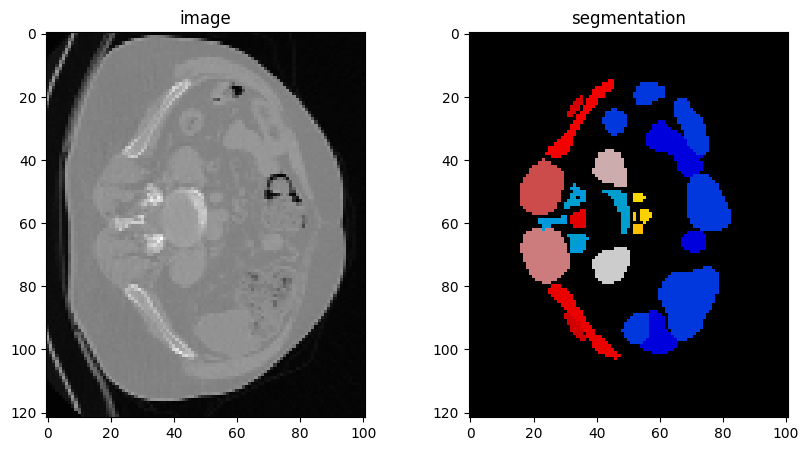

In [15]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
img = "/tmp/TotalSegmentator/tests/reference_files/example_ct.nii.gz"
seg = "/tmp/segmentations.nii"
img = nib.load(img).get_fdata()
seg = nib.load(seg).get_fdata()
slice_num = img.shape[-1]//2
assert img.shape == seg.shape, f"Shape 不匹配: img={img.shape}, seg={seg.shape}"
plt.figure("image", (10, 5))
plt.subplot(1, 2, 1)
plt.title("image")
plt.imshow(img[:, :, slice_num], cmap="gray")
plt.subplot(1, 2, 2)
plt.title("segmentation")
plt.imshow(
    seg[:, :, slice_num],
    cmap="nipy_spectral",        
    vmin=0,                       
    vmax=np.max(seg[:, :, slice_num]),
    interpolation="nearest"
)
plt.show()

---
本文档仅提供相关软件的配置与使用说明，不包含亦不分发前述软件的源代码或目标代码，且不涉及对其源代码的任何修改。您按照本文档配置、部署或使用相关软件时，应遵守适用许可证规定的条款及条件。相关软件的源代码、许可证全文、版权与归属声明及其他项目文档，请以其官方网站或原始发布页面为准。

### Copyright (c) 2026 MetaX Integrated Circuits (Shanghai) Co., Ltd. All rights reserved.